# 🗑️ — Waste Classifier ML

> ⚠️ **Notebook de unificación de datasets**  
> Ejecutar de arriba a abajo. Si hubo una interrupción previa, ejecutar
> la **Sección 3c** primero para saber desde dónde continuar.

---

| Campo | Valor |
|---|---|
| **Proyecto** | Waste Classifier — Clasificación Multiclase |
| **Datasets** | TrashNet · RealWaste · Garbage 12 clases |
| **Clases finales** | metal · vidrio · papel · carton · plastico · no_reciclable · organico |
| **Split** | 70% train · 15% val · 15% test |
| **Semilla** | 42 |


---
## 📚 Sección 0 — Imports

Carga todas las librerías necesarias de una sola vez al principio, para detectar dependencias faltantes antes de ejecutar código costoso. Esto facilita el mantenimiento y la detección temprana de dependencias faltantes.

In [ ]:
import os
import sys
import json
import random
import shutil
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False
    print("⚠️  Pillow no instalado")

print(f"✅ Imports OK")
print(f"   Python : {sys.version.split()[0]}")
print(f"   Pandas : {pd.__version__}")
print(f"   NumPy  : {np.__version__}")

✅ Imports OK
   Python : 3.12.12
   Pandas : 2.2.2
   NumPy  : 2.0.2


---
## ⚙️ Sección 1 — Configuración global

Definimos rutas, semilla y clases. Es la única celda que tocar si el proyecto cambia de ubicación o se añade una clase.

Lo hacemos para centralizar la configuración y evitar rutas hardcodeadas dispersas. La semilla fija garantiza que el split y cualquier operación aleatoria sea idéntica en cualquier ejecución.


In [ ]:
# ── Entorno ──
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/waste_classifier')
else:
    # notebooks/Jonathan/
    PROJECT_ROOT = Path().resolve().parent.parent

# ── Semilla global ──
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Rutas ──
PATHS = {
    'root':      PROJECT_ROOT,
    'raw':       PROJECT_ROOT / 'data' / 'raw',
    'processed': PROJECT_ROOT / 'data' / 'processed',
    'splits':    PROJECT_ROOT / 'data' / 'splits',
    'sources':   PROJECT_ROOT / 'data' / 'sources',
    'models':    PROJECT_ROOT / 'models',
    'logs':      PROJECT_ROOT / 'logs',
}

# ── Clases finales del proyecto ──
WASTE_CLASSES = ['metal', 'vidrio', 'papel', 'carton',
                'plastico', 'no_reciclable', 'organico']

# ── Total estimado para cálculo de progreso ──
TOTAL_EXPECTED = 11000

print(f"☁️ Colab   : {IN_COLAB}")
print(f"📂 ROOT    : {PROJECT_ROOT}")
print(f"🎲 SEED    : {RANDOM_SEED}")
print(f"🏷️ CLASES  : {WASTE_CLASSES}")

Mounted at /content/drive
☁️  Colab   : True
📂 ROOT    : /content/drive/MyDrive/waste_classifier
🎲 SEED    : 42
🏷️  CLASES  : ['metal', 'vidrio', 'papel', 'carton', 'plastico', 'no_reciclable', 'organico']


---
## 📁 Sección 2 — Estructura de carpetas

Creamos todas las carpetas del proyecto en drive. Operación idempotente — segura de re-ejecutar.

Garantizamos que cualquier celda que guarde archivos encuentre su carpeta destino. 

La estructura sigue el estándar industrial de proyectos ML: raw data separado del procesado, splits versionados como CSV y modelos en su propia carpeta.

In [ ]:
# Carpetas base
DIRS_TO_CREATE = [
    PATHS['sources'],
    PATHS['raw'],
    PATHS['processed'],
    PATHS['splits'],
    PATHS['models'],
    PATHS['logs'],
]

# Una subcarpeta por clase en raw/ y processed/
for cls in WASTE_CLASSES:
    DIRS_TO_CREATE.append(PATHS['raw'] / cls)
    DIRS_TO_CREATE.append(PATHS['processed'] / cls)

# Crear todo — exist_ok=True hace la operación idempotente
for d in DIRS_TO_CREATE:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Estructura de carpetas lista")
print(f"   📂 data/raw/      → {len(WASTE_CLASSES)} subcarpetas de clase")
print(f"   📂 data/processed → {len(WASTE_CLASSES)} subcarpetas de clase")
print(f"   📂 data/splits/   → train.csv · val.csv · test.csv")
print(f"   📂 data/sources/  → Datos brutos")
print(f"   📂 models/        → modelos entrenados")

✅ Estructura de carpetas lista
   📂 data/raw/      → 7 subcarpetas de clase
   📂 data/processed → 7 subcarpetas de clase
   📂 data/splits/   → train.csv · val.csv · test.csv (Sección 8)
   📂 models/        → modelos entrenados


---
## 🔎 Sección 3 — Unificar Datasets

### 3a — Configuración de datasets y mapeo de clases

Definimos las rutas de los 3 datasets en Drive y el diccionario que traduce los nombres de clase originales a los 7 nombres unificados del proyecto.

Cada dataset usa nombres distintos para la misma categoría. Sin este mapeo el modelo no sabe que `glass`, `Glass` y `green-glass` son la misma clase. Las clases no incluidas en el mapeo se ignoran automáticamente.

In [ ]:
# ── Rutas de los 3 datasets en Drive ──

DATASET_PATHS = {
    'trashnet':   PROJECT_ROOT / 'data' / 'sources' / 'trashnet',
    'realwaste':  PROJECT_ROOT / 'data' / 'sources' / 'realwaste',
    'garbage12':  PROJECT_ROOT / 'data' / 'sources' / 'garbage12',
}

# ── Mapeo: nombre original → clase unificada del proyecto ──
CLASS_MAPPING = {
    # TrashNet — nombres en minúscula
    'cardboard':      'carton',
    'paper':          'papel',
    'glass':          'vidrio',
    'metal':          'metal',
    'plastic':        'plastico',
    'trash':          'no_reciclable',
    # RealWaste — nombres con mayúscula inicial
    'Cardboard':      'carton',
    'Paper':          'papel',
    'Glass':          'vidrio',
    'Metal':          'metal',
    'Plastic':        'plastico',
    'Misc Trash':     'no_reciclable',
    'Food Organics':  'organico',
    # Garbage 12 clases
    'brown-glass':    'vidrio',
    'green-glass':    'vidrio',
    'white-glass':    'vidrio',
    'biological':     'organico',
    # Clases ignoradas — fuera del scope del proyecto
    # 'clothes'        → contenedor especial
    # 'shoes'          → contenedor especial
    # 'batteries'      → contenedor especial
    # 'Textile Trash'  → contenedor especial
    # 'Vegetation'     → fuera de scope
}

print('📋 Mapeo de clases:')
for src, dst in CLASS_MAPPING.items():
    print(f'   {src:<18} → {dst}')

📋 Mapeo de clases:
   cardboard          → carton
   paper              → papel
   glass              → vidrio
   metal              → metal
   plastic            → plastico
   trash              → no_reciclable
   Cardboard          → carton
   Paper              → papel
   Glass              → vidrio
   Metal              → metal
   Plastic            → plastico
   Misc Trash         → no_reciclable
   Food Organics      → organico
   brown-glass        → vidrio
   green-glass        → vidrio
   white-glass        → vidrio
   biological         → organico

🚫 Ignoradas: clothes · shoes · batteries · Textile Trash · Vegetation


---
### Sección 3b — Función de copia con verificación integrada

Definimos las dos funciones del pipeline de copia: `get_md5()` para detectar duplicados y `copy_dataset()` que verifica integridad, evita duplicados y copia en un solo paso.

La verificación está integrada **antes** de copiar — si una imagen está corrupta en el origen, nunca llega a `data/raw/`. Esto garantiza que todos los archivos en `data/raw/` son válidos.

In [ ]:
# ── Hash MD5 para detectar duplicados entre datasets ──
def get_md5(filepath):
    """Genera hash MD5 del contenido del archivo.
    Dos archivos con los mismos píxeles → mismo hash, aunque tengan distinto nombre.
    Nos ayuda a detectar imágnes duplicadas.
    """
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()


# ── Copia con verificación integrada ──
def copy_dataset(source_dir, dataset_name, class_mapping, dest_raw, seen_hashes):
    """
    Para cada imagen en source_dir:
        1. Verifica integridad con Pillow ANTES de copiar
        2. Comprueba hash MD5 — si ya existe, es duplicado → saltar
        3. Copia a dest_raw/<clase_unificada>/ con nombre único
    """
    copied, skipped_dup, skipped_corrupt = 0, 0, 0
    valid_ext = {'.jpg', '.jpeg', '.png', '.webp'}

    for src_class, dst_class in class_mapping.items():
        src_folder = source_dir / src_class
        if not src_folder.exists():
            continue

        dst_folder = dest_raw / dst_class

        for img_path in src_folder.iterdir():
            if img_path.suffix.lower() not in valid_ext:
                continue

            # ── Paso 1: verificar integridad antes de copiar ──
            try:
                Image.open(img_path).verify()
            except Exception:
                skipped_corrupt += 1
                continue  # Si existe una corrupta → nunca llega a raw/

            # ── Paso 2: detectar duplicados por hash MD5 ──
            file_hash = get_md5(img_path)
            if file_hash in seen_hashes:
                skipped_dup += 1
                continue

            # ── Paso 3: copiar con nombre único ──
            new_name  = f'{dataset_name}_{img_path.name}'
            dest_path = dst_folder / new_name
            shutil.copy2(img_path, dest_path)

            seen_hashes.add(file_hash)
            copied += 1

    return copied, skipped_dup, skipped_corrupt


print('✅ Funciones listas')
print('    get_md5()      → genera hash MD5 de un archivo')
print('    copy_dataset() → verifica + deduplica + copia')

✅ Funciones listas
   get_md5()      → genera hash MD5 de un archivo
   copy_dataset() → verifica + deduplica + copia


---
### Sección 3c — Diagnóstico del estado actual

Cuenta las imágenes que ya existen en `data/raw/` y calcula el progreso respecto al total esperado.

Esto nos permite tomar una decisión informada después de una interrupción (gestionar interrupciones de forma segura): si el progreso es alto conviene pre-poblar y continuar; si es bajo conviene limpiar y empezar desde cero.

In [ ]:
# ── Contar imágenes existentes en data/raw/ ───
valid_ext  = {'.jpg', '.jpeg', '.png', '.webp'}
total_actual = 0

print('📊 Estado actual de data/raw/:\n')
for cls in WASTE_CLASSES:
    cls_dir = PATHS['raw'] / cls
    if cls_dir.exists():
        n = len([f for f in cls_dir.iterdir()
                    if f.suffix.lower() in valid_ext])
    else:
        n = 0
    total_actual += n
    bar = '█' * (n // 50)
    print(f'   {cls:<15} {n:>5}  {bar}')

progreso = total_actual / TOTAL_EXPECTED * 100

print(f'\n   Total actual  : {total_actual:,}')
print(f'   Total esperado: ~{TOTAL_EXPECTED:,}')
print(f'   Progreso      : {progreso:.1f}%')

print('\n────────────────────────────────────────────────')
if total_actual == 0:
    print('▶️  ACCIÓN: Ejecuta 3e directamente (primera vez)')
elif progreso < 30:
    print('▶️  ACCIÓN: Poco progreso — considera limpiar y ejecutar 3e desde cero')
elif progreso < 95:
    print('▶️  ACCIÓN: Progreso parcial — ejecuta 3d (pre-poblar) y luego 3e')
else:
    print('✅ ACCIÓN: Copia completa — salta a Sección 4 directamente')

📊 Estado actual de data/raw/:

   metal            1558  ███████████████████████████████
   vidrio            921  ██████████████████
   papel            1550  ███████████████████████████████
   carton           1352  ███████████████████████████
   plastico         1407  ████████████████████████████
   no_reciclable     137  ██
   organico          411  ████████

   Total actual  : 7,336
   Total esperado: ~11,000
   Progreso      : 66.7%

─────────────────────────────────────────
▶️  ACCIÓN: Progreso parcial — ejecuta 3d (pre-poblar) y luego 3e
   La copia solo procesará lo que falta


In [16]:
# ── Celda de limpieza OPCIONAL ──
# Borra data/raw/<clases>/ y la recrea vacía

LIMPIAR = False  # Cambiar a True para limpiar

if LIMPIAR:
    print('🗑️  Limpiando data/raw/...')
    for cls in WASTE_CLASSES:
        cls_dir = PATHS['raw'] / cls
        if cls_dir.exists():
            shutil.rmtree(cls_dir)
            cls_dir.mkdir()
            print(f'   ✅ {cls}/ limpiada')
    print('\n✅ data/raw/ lista para empezar desde cero')
    print('   Siguiente paso: ejecuta 3e directamente')
else:
    print('ℹ️  Limpieza no ejecutada')

ℹ️  Limpieza no ejecutada


---
### Sección 3d — Pre-población de hashes

Lee las imágenes en `raw/` y carga sus hashes en memoria. Preparamos `seen_hashes` para que la Sección 3e sepa qué ya existe.

Sin esta celda, tras una interrupción la Sección 3e empezaría con `seen_hashes` vacío y reprocesaría todo desde cero. Ahora, solo copia lo que falta — puede ahorrar horas de procesamiento.

In [ ]:
# ── Pre-poblar seen_hashes con imágenes ya copiadas ──
# Si es primera vez o limpiaste, saltar esta celda

seen_hashes      = set()
total_cargados   = 0

print('🔍 Cargando hashes de imágenes existentes...')

for cls in WASTE_CLASSES:
    cls_dir = PATHS['raw'] / cls
    if not cls_dir.exists():
        continue
    n_cls = 0
    for fpath in cls_dir.iterdir():
        if fpath.suffix.lower() in valid_ext:
            seen_hashes.add(get_md5(fpath))
            n_cls += 1
    total_cargados += n_cls
    print(f'   {cls:<15} {n_cls:>5} hashes cargados')

print(f'\n✅ Total hashes en memoria : {total_cargados:,}')

🔍 Cargando hashes de imágenes existentes...
   metal            1558 hashes cargados
   vidrio            921 hashes cargados
   papel            1550 hashes cargados
   carton           1352 hashes cargados
   plastico         1407 hashes cargados
   no_reciclable     137 hashes cargados
   organico          411 hashes cargados

✅ Total hashes en memoria : 7,336
   La Sección 3e saltará estas imágenes automáticamente


---
### Sección 3e — Unificación de datasets

Copiamos los 3 datasets a `data/raw/` aplicando el mapeo de clases. Cada imagen pasa por verificación de integridad y deduplicación por MD5 antes de copiarse.

Produce un dataset unificado en `data/raw/` con 7 clases consistentes, sin corruptos y sin duplicados — listo para el pipeline de entrenamiento.

In [ ]:
# ── Si seen_hashes ya está poblado — no sobreescribir ──
if 'seen_hashes' not in dir():
    seen_hashes = set()
    print('ℹ️  seen_hashes inicializado vacío')
else:
    print(f'ℹ️  seen_hashes ya tiene {len(seen_hashes):,} hashes')

summary = {}
print('\n🔄 Iniciando unificación...\n')

for ds_name, ds_path in DATASET_PATHS.items():
    if not ds_path.exists():
        print(f'⚠️  No encontrado : {ds_path}')
        print(f'   Sube "{ds_name}" a Drive en esa ruta y re-ejecuta')
        continue

    c, d, corrupt = copy_dataset(
        ds_path, ds_name, CLASS_MAPPING,
        PATHS['raw'], seen_hashes
    )
    summary[ds_name] = c
    print(f'   {ds_name:<12} → {c:>5} copiadas · {d:>4} duplicadas · {corrupt:>3} corruptas descartadas')

print('\n📊 Conteo final por clase:')
total_final = 0
for cls in WASTE_CLASSES:
    cls_dir = PATHS['raw'] / cls
    n = len([f for f in cls_dir.iterdir()
            if f.suffix.lower() in valid_ext]) if cls_dir.exists() else 0
    total_final += n
    bar = '█' * (n // 50)
    print(f'   {cls:<15} {n:>5}  {bar}')

print(f'\n   Total : {total_final:,} imágenes')

# Alerta de desbalance
counts = [
    len(list((PATHS['raw'] / cls).iterdir()))
    for cls in WASTE_CLASSES
    if (PATHS['raw'] / cls).exists()
]
if counts:
    ratio = max(counts) / min(counts)
    print(f'   Ratio max/min: {ratio:.2f}x', end=' ')
    print('✅' if ratio <= 2 else '⚠️  Considera class_weight en el modelo')

ℹ️  seen_hashes ya tiene 7,336 hashes

🔄 Iniciando unificación...

   trashnet     →     0 copiadas · 2527 duplicadas ·   0 corruptas descartadas
   realwaste    →     0 copiadas · 3503 duplicadas ·   0 corruptas descartadas
   garbage12    →  3586 copiadas · 3682 duplicadas ·   0 corruptas descartadas

📊 Conteo final por clase:
   metal            1558  ███████████████████████████████
   vidrio           2444  ████████████████████████████████████████████████
   papel            1550  ███████████████████████████████
   carton           1352  ███████████████████████████
   plastico         1788  ███████████████████████████████████
   no_reciclable     834  ████████████████
   organico         1396  ███████████████████████████

   Total : 10,922 imágenes
   Ratio max/min: 2.93x ⚠️  Considera class_weight en el modelo


---
## 💽 Sección 4 — Escaneo del dataset unificado

Lee todas las imágenes de `data/raw/` y construye `df_master` — un DataFrame con una fila por imagen: ruta, clase, id numérico de clase y tamaño de archivo.

El DataFrame maestro nos ayuda: split, visualizaciones y pipeline de entrenamiento. Trabajar con un DataFrame nos permite operaciones vectorizadas, filtros y análisis estadísticos de forma eficiente.

In [9]:
label_map = {cls: idx for idx, cls in enumerate(WASTE_CLASSES)}
records   = []

for cls in WASTE_CLASSES:
    cls_dir = PATHS['raw'] / cls
    if not cls_dir.exists():
        continue
    for fpath in cls_dir.iterdir():
        if fpath.suffix.lower() not in valid_ext:
            continue
        records.append({
            'filepath':     str(fpath),
            'label':        cls,
            'label_id':     label_map[cls],
            'file_size_kb': round(fpath.stat().st_size / 1024, 2),
        })

df_master = pd.DataFrame(records)

print(f'✅ Dataset cargado: {len(df_master):,} imágenes · {df_master["label"].nunique()} clases')
print('\nDistribución por clase:')
dist = df_master['label'].value_counts()
for cls, count in dist.items():
    pct = count / len(df_master) * 100
    bar = '█' * int(pct / 2)
    print(f'   {cls:<15} {count:>5,}  {pct:>5.1f}%  {bar}')

✅ Dataset cargado: 10,922 imágenes · 7 clases

Distribución por clase:
   vidrio          2,444   22.4%  ███████████
   plastico        1,788   16.4%  ████████
   metal           1,558   14.3%  ███████
   papel           1,550   14.2%  ███████
   organico        1,396   12.8%  ██████
   carton          1,352   12.4%  ██████
   no_reciclable     834    7.6%  ███


---
## 📊 Sección 5 — Visualización de la distribución

Exponemos dos gráficos: barras horizontales con el conteo por clase y pie chart con la proporción.

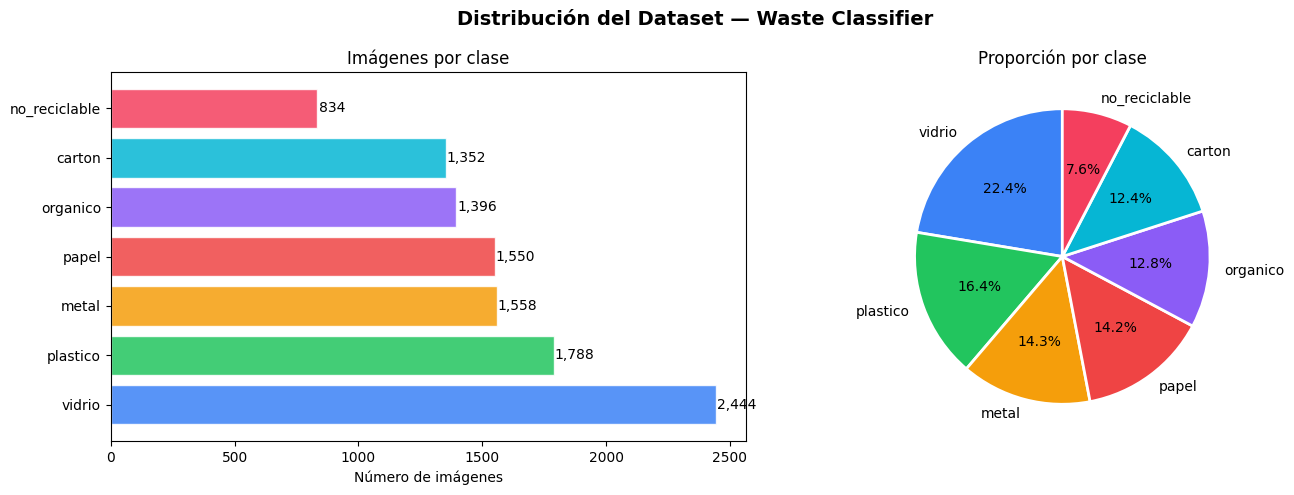

💾 Guardado: /content/drive/MyDrive/waste_classifier/logs/class_distribution.png

📊 Ratio max/min: 2.93x
   ⚠️  Desbalance moderado — usar StratifiedKFold


In [10]:
if df_master.empty:
    print('⏭️  Sin datos para visualizar')
else:
    class_counts = df_master['label'].value_counts()
    colors = ['#3b82f6','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4','#f43f5e']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribución del Dataset — Waste Classifier',
                 fontsize=14, fontweight='bold')

    # Barras horizontales
    bars = axes[0].barh(class_counts.index, class_counts.values,
                        color=colors[:len(class_counts)],
                        alpha=0.85, edgecolor='white')
    axes[0].set_title('Imágenes por clase')
    axes[0].set_xlabel('Número de imágenes')
    for bar, val in zip(bars, class_counts.values):
        axes[0].text(val + 5, bar.get_y() + bar.get_height() / 2,
                     f'{val:,}', va='center', fontsize=10)

    # Pie chart
    axes[1].pie(class_counts.values, labels=class_counts.index,
                colors=colors[:len(class_counts)], autopct='%1.1f%%',
                startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Proporción por clase')

    plt.tight_layout()
    fig_path = PATHS['logs'] / 'class_distribution.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Guardado: {fig_path}')

    ratio = class_counts.max() / class_counts.min()
    print(f'\n📊 Ratio max/min: {ratio:.2f}x')
    if ratio > 3:
        print('   ⚠️  Desbalance significativo — aplicar class_weight="balanced"')
    elif ratio > 1.5:
        print('   ⚠️  Desbalance moderado — usar StratifiedKFold')
    else:
        print('   ✅ Dataset bien balanceado')

---
## 🖼️ Sección 6 — Muestras visuales por clase

Grid de 3 imágenes de ejemplo por cada una de las 7 clases.

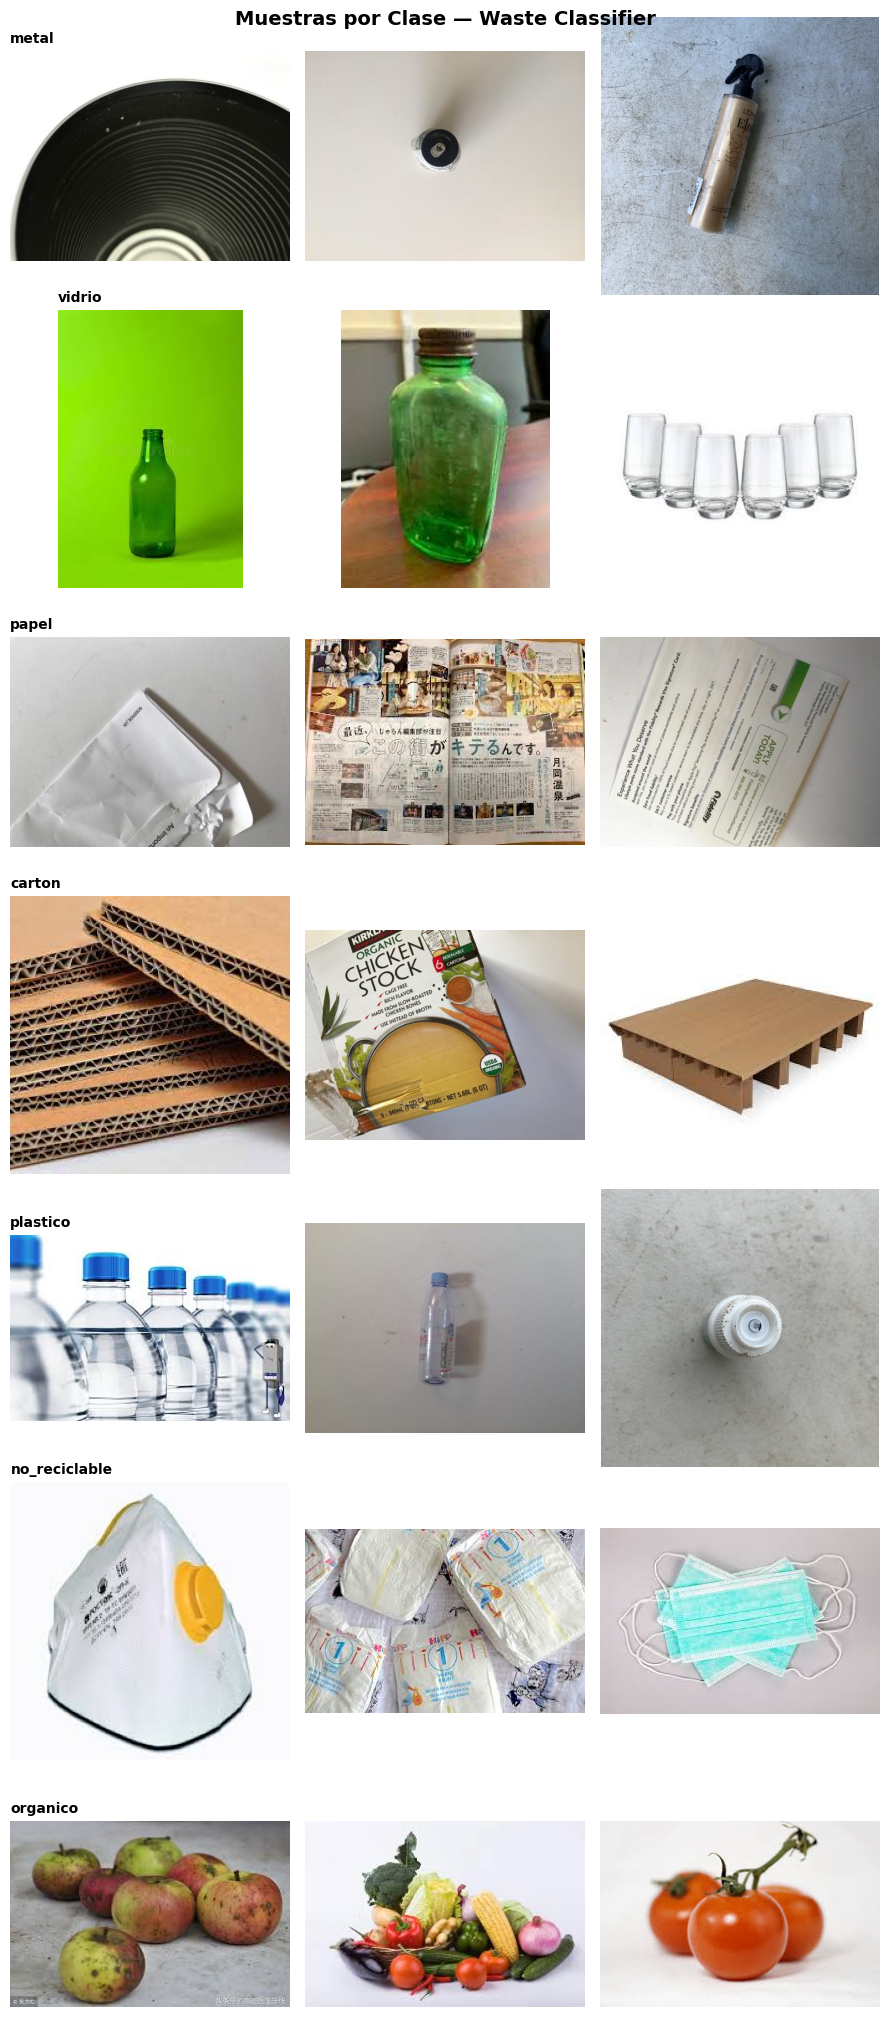

💾 Guardado: /content/drive/MyDrive/waste_classifier/logs/class_samples.png


In [ ]:
N_PER_CLASS = 3

if not PIL_AVAILABLE or df_master.empty:
    print('⏭️  Saltando visualización')
else:
    fig, axes = plt.subplots(len(WASTE_CLASSES), N_PER_CLASS,
                             figsize=(N_PER_CLASS * 3, len(WASTE_CLASSES) * 3))
    fig.suptitle('Muestras por Clase — Waste Classifier',
                    fontsize=14, fontweight='bold')

    for row_idx, cls in enumerate(WASTE_CLASSES):
        cls_df  = df_master[df_master['label'] == cls]
        samples = cls_df.sample(min(N_PER_CLASS, len(cls_df)),
                                random_state=RANDOM_SEED)

        for col_idx in range(N_PER_CLASS):
            ax = axes[row_idx][col_idx]
            if col_idx < len(samples):
                try:
                    ax.imshow(mpimg.imread(samples.iloc[col_idx]['filepath']))
                except Exception:
                    ax.text(0.5, 0.5, 'Error', ha='center', va='center')
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
            ax.axis('off')
            if col_idx == 0:
                ax.set_title(cls, fontsize=10, fontweight='bold', loc='left')

    plt.tight_layout()
    fig_path = PATHS['logs'] / 'class_samples.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'💾 Guardado: {fig_path}')

---
## 📇 Sección 7 — Split estratificado

Dividimos el dataset en train (70%), validación (15%) y test (15%) manteniendo las proporciones de clase. Los splits se guardan como CSV en `data/splits/`. Con esto garantizamos que cada partición tiene la misma distribución de clases que el dataset completo.

In [12]:
if df_master.empty:
    print('⏭️  Sin datos para generar splits')
else:
    existing = list(PATHS['splits'].glob('*.csv'))
    if existing:
        print('⚠️  Ya existen splits en data/splits/:')
        for sp in existing:
            print(f'   · {sp.name}: {pd.read_csv(sp).shape[0]:,} filas')
        print('\n   Para regenerar cambia REGENERATE = True')
        REGENERATE = False
    else:
        REGENERATE = True

    if REGENERATE:
        # Paso 1 — separar test
        df_trainval, df_test = train_test_split(
            df_master,
            test_size=0.15,
            stratify=df_master['label'],
            random_state=RANDOM_SEED
        )
        # Paso 2 — separar val del trainval
        df_train, df_val = train_test_split(
            df_trainval,
            test_size=0.15 / 0.85,
            stratify=df_trainval['label'],
            random_state=RANDOM_SEED
        )

        splits = {'train': df_train, 'val': df_val, 'test': df_test}
        cols   = ['filepath', 'label', 'label_id', 'file_size_kb']

        for name, sdf in splits.items():
            sdf[cols].to_csv(PATHS['splits'] / f'{name}.csv', index=False)

        print('✅ Splits generados:')
        for name, sdf in splits.items():
            pct = len(sdf) / len(df_master) * 100
            print(f'   {name:<6}: {len(sdf):>5,} ({pct:.1f}%)')

        print('\n📊 Distribución de clases por split:')
        dist_check = pd.DataFrame({
            name: sdf['label'].value_counts(normalize=True).round(3)
            for name, sdf in splits.items()
        })
        print(dist_check.to_string())
        print('\n   ⚠️  test.csv — SELLADO hasta la evaluación final')

✅ Splits generados:
   train : 7,644 (70.0%)
   val   : 1,639 (15.0%)
   test  : 1,639 (15.0%)

📊 Distribución de clases por split:
               train    val   test
label                             
vidrio         0.224  0.224  0.224
plastico       0.164  0.164  0.164
metal          0.143  0.143  0.143
papel          0.142  0.142  0.142
organico       0.128  0.128  0.128
carton         0.124  0.124  0.124
no_reciclable  0.076  0.076  0.076

   ⚠️  test.csv — SELLADO hasta la evaluación final


---
## 📝 Sección 8 — Manifiesto del dataset

Generamos `data/dataset_manifest.json` con los metadatos esenciales del dataset: fecha, semilla, imágenes por clase y tamaño de splits.

Que actúa como carné de identidad del dataset: esto permite saber en cualquier momento con qué datos se entrenó el modelo y reproducir exactamente el mismo experimento.

In [13]:
if df_master.empty:
    print('⏭️  Sin datos para generar manifiesto')
else:
    manifest = {
        'generated_at':  datetime.now().isoformat(),
        'random_seed':   RANDOM_SEED,
        'total_images':  len(df_master),
        'num_classes':   len(WASTE_CLASSES),
        'classes':       WASTE_CLASSES,
        'class_counts':  df_master['label'].value_counts().to_dict(),
        'balance_ratio': round(
            df_master['label'].value_counts().max() /
            df_master['label'].value_counts().min(), 3
        ),
        'splits': {
            name: len(pd.read_csv(PATHS['splits'] / f'{name}.csv'))
            for name in ['train', 'val', 'test']
            if (PATHS['splits'] / f'{name}.csv').exists()
        }
    }

    manifest_path = PATHS['root'] / 'data' / 'dataset_manifest.json'
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(manifest, f, indent=2, ensure_ascii=False)

    print(f'✅ Manifiesto guardado: {manifest_path}')
    print(json.dumps(manifest, indent=2, ensure_ascii=False))

✅ Manifiesto guardado: /content/drive/MyDrive/waste_classifier/data/dataset_manifest.json
{
  "generated_at": "2026-03-17T09:32:33.648850",
  "random_seed": 42,
  "total_images": 10922,
  "num_classes": 7,
  "classes": [
    "metal",
    "vidrio",
    "papel",
    "carton",
    "plastico",
    "no_reciclable",
    "organico"
  ],
  "class_counts": {
    "vidrio": 2444,
    "plastico": 1788,
    "metal": 1558,
    "papel": 1550,
    "organico": 1396,
    "carton": 1352,
    "no_reciclable": 834
  },
  "balance_ratio": 2.93,
  "splits": {
    "train": 7644,
    "val": 1639,
    "test": 1639
  }
}


---
## ✅ Fase 1 completada

| Archivo generado | Ubicación |
|---|---|
| Imágenes unificadas | `data/raw/<clase>/` |
| train.csv | `data/splits/train.csv` |
| val.csv | `data/splits/val.csv` |
| test.csv | `data/splits/test.csv` ⚠️ no tocar hasta evaluación final |
| dataset_manifest.json | `data/dataset_manifest.json` |
| class_distribution.png | `logs/class_distribution.png` |
| class_samples.png | `logs/class_samples.png` |


